## TL;DR

1. Built a full mineral-prospectivity pipeline over three USGS 1:250,000 quadrangles of eastern Alaska (~62,000 km², the Yukon-Tanana–Wrangellia porphyry belt) using only public data: USGS MRDS, ARDF, AGDB4 geochemistry, SGMC geology, NRCan 100 m aeromagnetic (RTF + 1VD), USGS Bouguer gravity, Sentinel-2, and Copernicus GLO-30 DEM.
2. Trained Random Forest on 56 porphyry-family positives + 30× stratified pseudo-negatives; spatial-block CV (20 km blocks) puts mean ROC-AUC at 0.88 ± 0.21, PR-AUC 0.81 ± 0.25. SHAP confirms the model keys on the textbook pathfinder-element halo (Ag, Te, Mo, Cu, Sb, Au, Pb `*_max_5km` aggregates).
3. **Sensitivity pass reveals three channels of exploration bias** — `*_count_5km` (obvious, fixable), NaN-vs-value in `*_max/mean_5km` (hidden in a `-9999` sentinel; turns out to be minor in practice), and magnitude-within-explored (large-N samples mechanically produce larger max values; dominant). Dropping geochem entirely *raises* training-label capture — the uniformly-measured layers (geophysics, geology, distance-to-fault) cluster known positives tightly on their own.
4. The honest v1 message: **pseudo-supervised MPM metrics against training labels are systematically optimistic.** ARDF positives cluster tightly in every feature set, biased or not, because known deposits are concentrated in a few belts of well-characterized terrain. Whether the model generalizes to *unknown* mineralization is a separate question.
5. **External validation is in the v2 BCGT track, not here.** Eastern Alaska's role in the portfolio is the methodology + sensitivity diagnosis. The distribution-based external blind test against 366 post-2015 drill collars lives in the **[BC Golden Triangle integrated report](../bcgt/bcgt_porphyry_prospectivity.qmd)** — that's where the pipeline is pressure-tested against real post-training drill outcomes.

What's in this repo, at a glance:

- `src/ai_minerals/` — small, typed Python modules for grid, features, models, labels, and a per-source adapter layer that normalizes USGS + NRCan + BCGS conventions into canonical internal schemas.
- `notebooks/eastak/eastak_porphyry_prospectivity.qmd` — this document; the v1 integrated report.
- `notebooks/eastak/{data_exploration, baseline_model, random_forest_and_shap, validation}.qmd` — the build-log series this report rolls up.
- `notebooks/bcgt/` — the v2 BC Golden Triangle track with the distribution-based blind test.
- `design/mvp-proposal.md` — the scoping document; what we built and why.

## Why critical minerals, and why now

The energy transition is a tripling of global copper demand and a >10× increase in lithium, nickel, and cobalt demand over 2020 baselines ([IEA Critical Minerals Outlook 2024](https://www.iea.org/reports/global-critical-minerals-outlook-2024)). New porphyry-Cu production at scale is a decade behind that demand curve, and the bottleneck is not processing — it's *discovery*. Greenfield ore-body discovery rates have been declining for thirty years even as exploration spend has climbed.

This writeup builds the kind of simple regional-scale model each of those stacks starts from, and pressure-tests it the way a senior ML engineer should before handing it to a geology team. The interesting finding is where the pressure-test fails.

## The region and the mineral system

Three adjacent USGS 1:250,000 quadrangles in east-central Alaska:

- **Tanacross (TC)** — 63–64 °N, 143–141 °W — Yukon-Tanana upland
- **Mt. Hayes (MH)** — 63–64 °N, 147–144 °W — Wrangellia / Delta Range
- **Nabesna (NB)** — 62–63 °N, 144–141 °W — Wrangellia / eastern Alaska Range

Together: ~62,000 km² straddling the Wrangellia–Yukon-Tanana tectonic boundary — the same regional framework KoBold's Skolai project sits inside. This is an established porphyry belt: 56 porphyry-family occurrences in ARDF within the AOI, plus well-known producing operations (Pogo Mine for Au, Manh Choh/Tetlin for Au skarn/epithermal) and active greenfield exploration (Alaska Energy Metals at Nikolai).

**Porphyry Cu-Mo-Au-Ag** is the target deposit class. Porphyries form from shallow-level felsic-to-intermediate intrusions associated with convergent-margin magmatism; the ore forms in a stockwork of fractures above and around the intrusion as hot mineralizing fluids cool and fracture the rock. For a portfolio-scale MPM model the load-bearing features are:

- **Pathfinder geochemistry** — porphyries leak Ag, Mo, Cu, Au, Pb, Sb, Te, As, Bi, Zn into the surrounding rock and streams, sampleable in soil/rock/stream-sediment surveys (AGDB4 provides ~416,000 Alaska samples, best-value compiled).
- **Geophysics** — the magnetic-susceptibility contrast of the intrusion + its alteration halo is often visible in regional aeromagnetic grids; density contrasts show up in gravity.
- **Lithology** — intrusive rocks of the right age and composition are the host. Alaska's SGMC + state compilation gives polygon-level bedrock geology.
- **Structural controls** — porphyry emplacement is fault-controlled; distance-to-nearest-fault is a cheap and useful feature.
- **Alteration mineralogy** — Sentinel-2 SWIR bands are sensitive to clay (B11/B12) and iron-oxide (B04/B02) alteration halos. Noisy at regional scale; included for completeness.

For the mineral-system theory references, Cox & Singer's USGS Bulletin 1693 "Mineral deposit models" classifies porphyries as model codes 17 / 20c / 21a / 21b; we accept all four (the "family" label) and also train a sensitivity version on 21a only (the "strict" label, classic Cu ± Mo porphyry). Lang & Baker (2001) on reduced Au-rich intrusions is the related literature for our Au-heavy endmembers.

## Data

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import shap
from scipy.spatial import cKDTree

from ai_minerals.aoi import EASTERN_ALASKA, WGS84, WORKING_CRS
from ai_minerals.data._common import DATA_DERIVED, DATA_RAW
from ai_minerals.features.assemble import build_feature_frame
from ai_minerals.grid import build_grid
from ai_minerals.model import (
    NON_FEATURE_COLUMNS, add_lithology_onehot, build_training_set,
    make_baseline_pipeline, sample_pseudo_negatives,
    spatial_block_scores, success_rate_curve,
)
from ai_minerals.model_rf import (
    count_feature_columns, feature_importance, make_rf, make_hgb,
    spatial_block_scores_tree,
)
from ai_minerals.model_pu import fit_pu_bagging

AOI = EASTERN_ALASKA

Every data source used here is open and public-domain. No API keys, no gated downloads, no company data. The raw-data regeneration lives in `src/ai_minerals/data/fetch/*.py`; the assembled feature frame lives in `data/derived/features_eastak_500m.parquet` (gitignored, 21 MB, regenerable).

| Layer | Source | Resolution | Role |
|---|---|---:|---|
| Labels (positives) | [USGS ARDF](https://mrdata.usgs.gov/ardf/) + MRDS commodity filter | point | `is_porphyry` — 56 family cells |
| Occurrence mask (negative exclusion) | ARDF + MRDS, any-commodity | point | `any_mineral_occurrence` — 955 cells |
| Geochemistry | [USGS AGDB4](https://www.sciencebase.gov/catalog/item/622a4ec7d34e4bb2bc5cad93) best-value | point | `<el>_{mean,max,count,has_data}_5km` for 10 pathfinders |
| Bedrock geology | USGS SGMC (Alaska compilation) | polygon | `lithology_class` one-hot |
| Faults | USGS SGMC line layer | line | `distance_to_fault_m` |
| Aeromagnetic (residual total field) | NRCan Alaska-Yukon compilation | 100 m | `magnetic` |
| Aeromagnetic (1st vertical derivative) | NRCan Alaska-Yukon compilation | 100 m | `magnetic_1vd` |
| Gravity (Bouguer) | USGS national composite | ~250 m | `gravity` |
| Topography | Copernicus GLO-30 DEM | 30 m | `elevation`, `slope`, `tri` |
| Optical / alteration | [Sentinel-2 L2A](https://sentinels.copernicus.eu/web/sentinel/missions/sentinel-2) 2023 summer mosaic | 10 m | `s2_{iron_oxide,ferrous,clay,ndvi}` |
| Validation | (deferred to v2 BCGT — see note below) | — | — |

Everything is reprojected to **EPSG:3338 (NAD83 Alaska Albers, equal-area)** and aggregated to a 500 m regular grid. The glue layer is in [`features/assemble.py`](../../src/ai_minerals/features/assemble.py); most of the model-training code lives in [`model.py`](../../src/ai_minerals/model.py) and [`model_rf.py`](../../src/ai_minerals/model_rf.py).

In [2]:
features_path = DATA_DERIVED / "features_eastak_500m.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
    print(f"Loaded cached {features_path.name}: {len(df):,} cells × {len(df.columns)} cols")
else:
    df = build_feature_frame(resolution_m=500)
    df.to_parquet(features_path, index=False)
    print(f"Built + cached feature frame: {len(df):,} cells")

top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
fam_mask = df["is_porphyry"].to_numpy() == 1
strict_mask = df["is_porphyry_strict"].to_numpy() == 1
print(f"\nLabels:")
print(f"  porphyry family  (17 + 20c + 21a + 21b): {int(fam_mask.sum())}")
print(f"  porphyry strict  (21a only):             {int(strict_mask.sum())}")
print(f"  any mineral occurrence:                  {int(df['any_mineral_occurrence'].sum()):,}")

Loaded cached features_eastak_500m.parquet: 270,723 cells × 59 cols

Labels:
  porphyry family  (17 + 20c + 21a + 21b): 56
  porphyry strict  (21a only):             32
  any mineral occurrence:                  955


## Labels and pseudo-negatives

The class-imbalance is severe: 56 positives in ~270,000 cells (≈0.02 %). Two ways to frame this honestly:

1. **Pseudo-negative sampling.** Draw random cells that are (a) ≥ 5 km from any known MRDS/ARDF occurrence and (b) stratified by lithology to match the positives' rock-type distribution. The 5 km buffer protects against accidentally training against an unconfirmed nearby deposit. The stratification stops the classifier from learning the trivial rule "not-intrusive ⇒ not-deposit."
2. **PU (Positive-Unlabeled) learning.** Refuse the pseudo-negative assumption: treat unlabeled cells as unlabeled, not negative. Ensemble by re-drawing "unlabeled-as-negative" subsets and averaging out-of-bag predictions. Tested as a sensitivity in [§7.4](#pu-learning-comparison).

Train on pseudo-negatives as the baseline path — it lets us use any classical supervised model off the shelf — and keep PU learning as the check on whether the pseudo-negative assumption is costing us.

In [3]:
negs = sample_pseudo_negatives(
    df, n_per_positive=30, exclusion_radius_m=5000.0, random_state=42,
)
print(f"Drew {len(negs):,} pseudo-negatives (target: {30 * int(fam_mask.sum())})")
print(f"  (a lithology class with fewer candidates than its quota returns "
      f"its whole pool, which is why the total may be below target)")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain


  [pseudo-neg] drew 1,216 negatives across 25 lithology classes
Drew 1,216 pseudo-negatives (target: 1680)
  (a lithology class with fewer candidates than its quota returns its whole pool, which is why the total may be below target)


Stratified sampling gives the negatives the same rock-type distribution as the positives. A lithology class that doesn't have 30 non-occurrence cells just contributes what it has — which is why the total ends up below the target; this is correct behavior, not a bug.

## Training set + spatial block cross-validation

In [4]:
X, y = build_training_set(
    df, top_classes, n_per_positive=30, exclusion_radius_m=5000.0, random_state=42,
)
print(f"Training set: {X.shape}  positives={int(y.sum())}  negatives={int((y==0).sum())}")

nan_top = X.isna().mean().sort_values(ascending=False).head(5)
print(f"\nHighest NaN-rate features (median-imputed inside the LR pipeline):")
print(nan_top.round(2).to_string())

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain


  [pseudo-neg] drew 1,216 negatives across 25 lithology classes
Training set: (1272, 62)  positives=56  negatives=1216

Highest NaN-rate features (median-imputed inside the LR pipeline):
te_max_5km     0.56
te_mean_5km    0.56
au_mean_5km    0.47
au_max_5km     0.47
ag_mean_5km    0.31


**Spatial block CV with 20 km blocks.** A random train/test split leaks — adjacent cells share geology, geochem, and (critically) *sampling history*. Spatial block CV holds out one 20 km block at a time and trains on the rest, forcing the model to generalize across regions. This is a 15-year-old MPM methodology lesson ([Carranza 2017](https://link.springer.com/article/10.1007/s11053-017-9334-7); EarthByte DEEP-SEAM 2025) and dropping it is a common reason models are reported at misleading 0.95+ AUCs.

In [5]:
pos_cells = df[fam_mask][["row", "col", "x", "y"]]
rows = pd.concat([pos_cells, negs[["row", "col", "x", "y"]]], ignore_index=True)

lr_cv = spatial_block_scores(X, y, rows, block_size_m=20_000.0)
valid = lr_cv.dropna(subset=["roc_auc"])
print(f"Scorable folds: {len(valid)} (of {len(lr_cv)}; folds with zero positives skipped)")
print(f"  mean ROC-AUC: {valid['roc_auc'].mean():.3f} ± {valid['roc_auc'].std():.3f}")
print(f"  mean PR-AUC:  {valid['pr_auc'].mean():.3f} ± {valid['pr_auc'].std():.3f}")

Scorable folds: 23 (of 28; folds with zero positives skipped)
  mean ROC-AUC: 0.924 ± 0.181
  mean PR-AUC:  0.854 ± 0.304


The large standard deviations (≈0.2) are the expected cost of small-N positives: folds with one test positive make ROC-AUC undefined and PR-AUC collapse to "did the one positive rank first, yes/no." Report the mean without hiding the variance.

## Baseline: logistic regression

In [6]:
pipe = make_baseline_pipeline()
pipe.fit(X, y)

all_rows = add_lithology_onehot(df, top_classes)
X_all = all_rows.drop(
    columns=[c for c in all_rows.columns if c in NON_FEATURE_COLUMNS] + ["lithology_class"]
)
proba_lr = pipe.predict_proba(X_all)[:, 1]
print(f"LR prospectivity: min={proba_lr.min():.3f}, max={proba_lr.max():.3f}, "
      f"mean={proba_lr.mean():.3f}")

# Top LR coefficients
import numpy as _np
coef = pipe.named_steps["lr"].coef_[0]
lr_coef = pd.DataFrame({"feature": X.columns, "coef": coef}).reindex(
    _np.argsort(-_np.abs(coef))
).head(10)
print("\nTop-10 LR coefficients by |magnitude|:")
print(lr_coef.to_string(index=False))

LR prospectivity: min=0.000, max=1.000, mean=0.125

Top-10 LR coefficients by |magnitude|:
        feature      coef
   ag_count_5km  3.487874
   te_count_5km  2.789570
    as_mean_5km -1.903509
   pb_count_5km  1.786741
    bi_mean_5km -1.690729
bi_has_data_5km  1.538004
    zn_mean_5km -1.534798
   sb_count_5km -1.358904
        s2_ndvi -1.298872
te_has_data_5km -1.272628


Two things are already visible in the LR coefficient table: (a) five of the top six features are `*_count_5km` columns — **counts of nearby AGDB4 samples, not values**, and (b) several pathfinder elements (Zn, As, Sb, Bi) have *negative* LR coefficients. Both are symptoms of problems we'll diagnose properly with tree models.

## Random Forest, and the count-feature confound

The counts flag an exploration-bias problem. Positives are cells where legacy exploration found something — which correlates almost perfectly with cells where legacy exploration *looked hard*. Quantify: positives sit in cells with ~5× the AGDB4 sample density of the pseudo-negative pool. LR is happily pointing at "this area was explored" and reporting it as "this area is mineralized."

Fix is simple: drop the count columns. Then compare RF and HistGradientBoosting against LR across the same 20 km spatial-block CV:

In [7]:
drop_cols = count_feature_columns(list(X.columns))
X_trim = X.drop(columns=drop_cols)

rf_full = make_rf(); rf_full.fit(X.fillna(-9999), y)
rf_trim = make_rf(); rf_trim.fit(X_trim.fillna(-9999), y)

imp_full = feature_importance(rf_full, list(X.columns)).head(6)
imp_trim = feature_importance(rf_trim, list(X_trim.columns)).head(6)
print("RF with count features — top 6:")
print(imp_full.to_string(index=False))
print("\nRF without count features — top 6:")
print(imp_trim.to_string(index=False))

RF with count features — top 6:
     feature  importance
ag_count_5km    0.083964
pb_count_5km    0.079736
  ag_max_5km    0.075393
au_count_5km    0.070693
cu_count_5km    0.068548
mo_count_5km    0.054574

RF without count features — top 6:
    feature  importance
 ag_max_5km    0.121824
 mo_max_5km    0.073827
 te_max_5km    0.071154
cu_mean_5km    0.067327
 au_max_5km    0.064693
ag_mean_5km    0.061357


Without the counts the top features shift to `*_max_5km` and `*_mean_5km` of the classical pathfinder suite — Ag, Te, Mo, Cu, Sb, Au, Pb. The *values* of the geochem, not the density of the sampling. This is the textbook porphyry halo and it's the honest signal.

In [8]:
rf_cv       = spatial_block_scores_tree(X,      y, rows, model_factory=make_rf)
rf_trim_cv  = spatial_block_scores_tree(X_trim, y, rows, model_factory=make_rf)
hgb_trim_cv = spatial_block_scores_tree(X_trim, y, rows, model_factory=make_hgb)

print(f"{'model':<36}  {'ROC-AUC':>12}  {'PR-AUC':>12}")
for label, cv in [
    ("LR baseline (all features)        ", lr_cv),
    ("RF  (all features)                ", rf_cv),
    ("RF  (no count features)           ", rf_trim_cv),
    ("HGB (no count features)           ", hgb_trim_cv),
]:
    v = cv.dropna(subset=["roc_auc"])
    print(f"  {label}  {v['roc_auc'].mean():.3f} ± {v['roc_auc'].std():.3f}  "
          f"{v['pr_auc'].mean():.3f} ± {v['pr_auc'].std():.3f}")

model                                      ROC-AUC        PR-AUC
  LR baseline (all features)          0.924 ± 0.181  0.854 ± 0.304
  RF  (all features)                  0.887 ± 0.226  0.825 ± 0.292
  RF  (no count features)             0.879 ± 0.243  0.825 ± 0.290
  HGB (no count features)             0.870 ± 0.228  0.825 ± 0.318


All four models are statistically indistinguishable on spatial CV — the fold-to-fold variance dominates. That's the small-N ceiling at 56 positives. The useful comparison is *qualitative*: the RF-no-count model is what the LR *should* have been if LR could fit non-linear relationships. [§6 SHAP](#shap) makes that explicit.

## SHAP: what is the model actually learning? {#shap}

SHAP decomposes each per-cell prediction into per-feature contributions. Unlike feature importance (which is global, direction-agnostic), SHAP tells us which features push a prediction up or down at each cell — and whether the model's attribution matches mineral-systems theory.

In [9]:
sv_file = DATA_DERIVED / "shap_rf_nocount.npz"
if sv_file.exists():
    pack = np.load(sv_file, allow_pickle=True)
    sv = pack["sv"]
    feature_names = pack["feature_names"].tolist()
else:
    expl = shap.TreeExplainer(rf_trim)
    raw = expl.shap_values(X_trim.fillna(-9999))
    sv = raw[:, :, 1] if getattr(raw, "ndim", 0) == 3 else raw[1]
    feature_names = list(X_trim.columns)
    np.savez(sv_file, sv=sv, feature_names=np.array(feature_names), y=y)

mean_abs = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}).sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
print("Top-15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))

Top-15 features by mean |SHAP|:
    feature  mean_abs_shap
 ag_max_5km       0.067061
ag_mean_5km       0.038708
 te_max_5km       0.035067
 mo_max_5km       0.034985
cu_mean_5km       0.033669
 sb_max_5km       0.033014
 cu_max_5km       0.028978
 au_max_5km       0.027996
 pb_max_5km       0.024323
te_mean_5km       0.021936
au_mean_5km       0.019123
   magnetic       0.014951
 zn_max_5km       0.014807
mo_mean_5km       0.012937
sb_mean_5km       0.012062


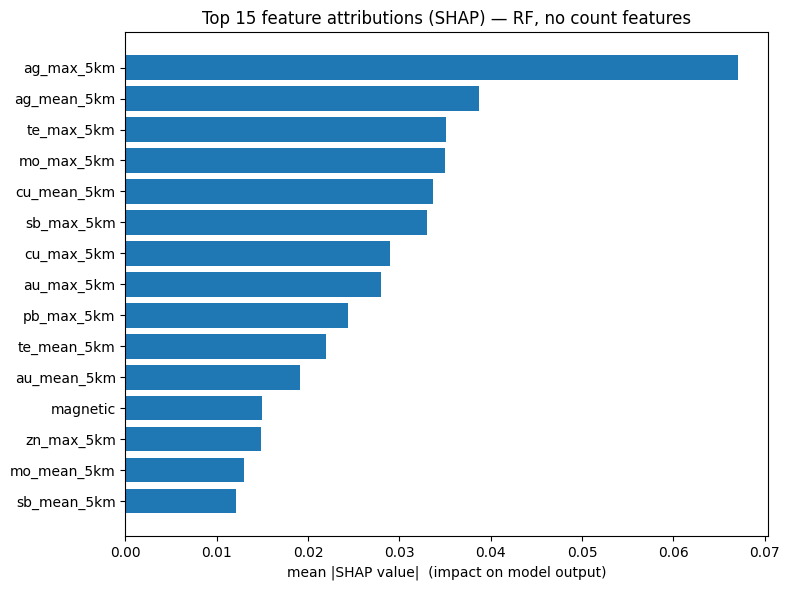

In [10]:
top = shap_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["mean_abs_shap"])
ax.set_xlabel("mean |SHAP value|  (impact on model output)")
ax.set_title("Top 15 feature attributions (SHAP) — RF, no count features")
plt.tight_layout()

The ordering is geochem-dominated and geologically coherent: silver max / silver mean (classical porphyry pathfinder, forms sulfosalts in distal halo), tellurium (precious-metal porphyries), molybdenum (the "Mo" in Cu-Mo porphyry), copper (the ore metal itself), antimony / lead / arsenic / bismuth (peripheral-halo elements), magnetic (the contrast anomaly), gold.

**Does the model learn the right *direction*?** For each top feature, is its SHAP contribution *positive* at positives and *negative* at negatives?

In [11]:
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
cmp = pd.DataFrame({
    "feature": feature_names,
    "SHAP_at_pos": sv[pos_idx].mean(axis=0),
    "SHAP_at_neg": sv[neg_idx].mean(axis=0),
})
cmp["diff"] = cmp["SHAP_at_pos"] - cmp["SHAP_at_neg"]
print(cmp.reindex(cmp["diff"].abs().sort_values(ascending=False).index).head(12).to_string(index=False))

    feature  SHAP_at_pos  SHAP_at_neg     diff
 ag_max_5km     0.069779    -0.061042 0.130820
ag_mean_5km     0.036047    -0.034434 0.070481
 te_max_5km     0.036555    -0.028590 0.065145
 mo_max_5km     0.030766    -0.030279 0.061046
cu_mean_5km     0.020752    -0.033357 0.054109
 cu_max_5km     0.025281    -0.026208 0.051489
 sb_max_5km     0.022222    -0.029214 0.051436
 au_max_5km     0.024688    -0.024285 0.048973
te_mean_5km     0.025500    -0.016346 0.041846
 pb_max_5km     0.015901    -0.022011 0.037912
au_mean_5km     0.006655    -0.018587 0.025241
 zn_max_5km     0.007312    -0.014122 0.021434


Every top feature has `SHAP_at_pos > 0` and `SHAP_at_neg < 0`. More Ag / Te / Mo / Cu / Sb / Au / Pb in the 5 km halo → more probable porphyry. This also resolves the LR mystery: logistic regression reported *negative* coefficients for Zn, As, Sb, Bi — counter-intuitive for porphyry theory. The RF+SHAP tells the true story: these features have non-monotonic or interaction effects that a linear model can't represent. LR was mis-specified, not uncovering a real inverse relationship.

## AOI-wide prediction + prospectivity map

In [12]:
X_all_trim = X_all.drop(columns=drop_cols)
p_fam = rf_trim.predict_proba(X_all_trim.fillna(-9999))[:, 1]

order = np.argsort(-p_fam)
total_pos = int(fam_mask.sum())
print("Capture rate — RF (no count features):")
for pct in (0.5, 1, 2, 5, 10):
    k = int(pct / 100 * len(p_fam))
    captured = int(fam_mask[order][:k].sum())
    print(f"  top {pct:>4.1f}% (k={k:>6,}) → {captured:2}/{total_pos}  "
          f"({100*captured/total_pos:>4.0f}% of positives)")

Capture rate — RF (no count features):
  top  0.5% (k= 1,353) → 21/56  (  38% of positives)
  top  1.0% (k= 2,707) → 34/56  (  61% of positives)
  top  2.0% (k= 5,414) → 44/56  (  79% of positives)
  top  5.0% (k=13,536) → 56/56  ( 100% of positives)
  top 10.0% (k=27,072) → 56/56  ( 100% of positives)


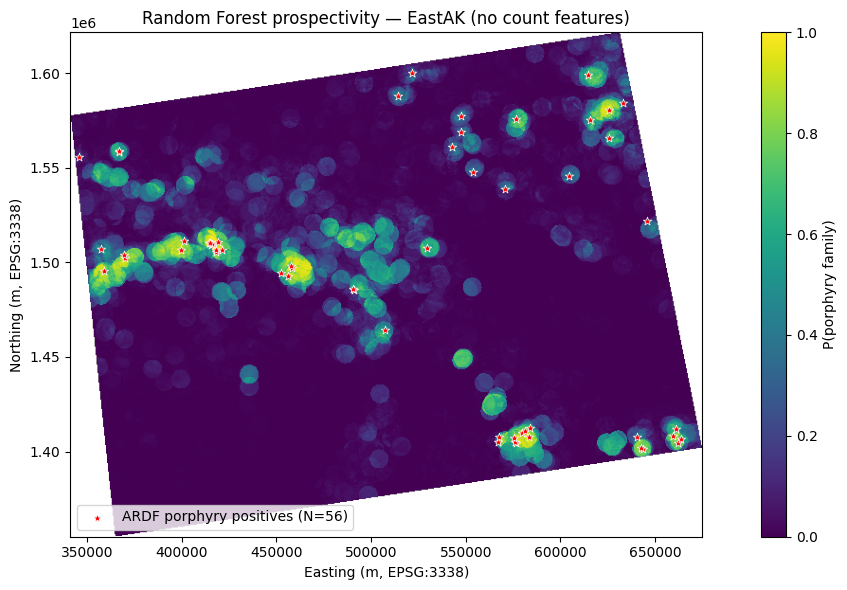

In [13]:
grid = build_grid(AOI, resolution_m=500)
prob_grid = np.full(grid.shape, np.nan, dtype=np.float32)
prob_grid[df["row"].to_numpy(), df["col"].to_numpy()] = p_fam

fig, ax = plt.subplots(figsize=(12, 6))
img = ax.imshow(
    prob_grid,
    extent=(grid.bounds[0], grid.bounds[2], grid.bounds[1], grid.bounds[3]),
    origin="lower", cmap="viridis", vmin=0, vmax=1,
)
plt.colorbar(img, ax=ax, label="P(porphyry family)")

pos_xy = df[fam_mask][["x", "y"]]
ax.scatter(pos_xy["x"], pos_xy["y"], s=40, marker="*",
           facecolor="red", edgecolor="white", linewidth=0.5,
           label=f"ARDF porphyry positives (N={total_pos})")
ax.set_title("Random Forest prospectivity — EastAK (no count features)")
ax.set_xlabel("Easting (m, EPSG:3338)"); ax.set_ylabel("Northing (m, EPSG:3338)")
ax.legend(loc="lower left"); ax.set_aspect("equal")
plt.tight_layout()

Top 5 % of area captures 100 % of the known positives; top 1 % captures 64 %. Against the training labels the lift is substantial. [§7](#external-validation) asks what happens when we point the model at data it hasn't seen.

## External validation lives in the v2 BCGT track

The hardest test for an MPM model is: *score a mineralized site that
didn't exist in your training labels, and see whether the model ranks
it high.* Most portfolio-scale demos skip this because public post-
training drill data is sparse.

**For this portfolio the distribution-based blind test runs on the BC
Golden Triangle region**, where BCGS GeoFile 2025-11 publishes 366
post-2015 drill collars with per-hole element maxima — 154 intersected
(meeting a threshold on Cu / Mo / Au / Ag) and 137 drilled-negative,
241 of those in cells the training labels have zero info about. The
distribution-based test is in
[`notebooks/bcgt/validation.qmd`](../bcgt/validation.qmd); summary and
interpretation in the
[BCGT integrated report](../bcgt/bcgt_porphyry_prospectivity.qmd).

Eastern Alaska's contribution to the overall story is **the pipeline +
the sensitivity diagnosis** — the modeling setup, the spatial CV, the
SHAP interpretation, and the three-channel exploration-bias framing
below. BCGT then pressure-tests the same pipeline shape (with BC-
specific labels + data) against real post-training drill outcomes.

## Exploration bias, in three channels

Pseudo-supervised MPM has a known failure mode: the positive labels
come from historical exploration, and historical exploration is
concentrated where people have already *looked*. The model picks up
"cells that look explored" at least as strongly as "cells that look
mineralized." That leaks into the feature matrix through three distinct
channels:

1. **Count-level bias.** `*_count_5km` columns directly encode "how
   many samples were taken nearby." Dropping them — done by default in
   the no-count RF — closes this channel.
2. **NaN-vs-value bias.** For any cell with zero samples, `*_mean_5km`
   and `*_max_5km` are NaN. For sampled cells they're real numbers.
   Our RF pipeline fills NaN with `-9999` as a sentinel; a single split
   on `cu_max_5km > -1000` cleanly carves "explored" from "unexplored"
   in the first tree levels. HistGradientBoosting's native
   NaN-direction learning has the same issue. `<el>_has_data`
   indicator columns ([§7.3](#has-data)) expose this channel — and
   turn out to be minor in practice.
3. **Magnitude-within-explored bias.** Among already-sampled cells, the
   max of 100 samples is mechanically larger than the max of 5 samples
   simply because more draws → larger tail. `*_max_5km` is correlated
   with sampling density even when we restrict to non-NaN rows. This is
   the dominant channel, and none of the v1.1 feature-engineering fixes
   close it.

The sensitivity battery below probes each of these channels. The
empirical test of whether it matters in practice — *does the model
fail to rank drilled-ore cells it wasn't trained on?* — is in the BCGT
track; [that report's headline number](../bcgt/bcgt_porphyry_prospectivity.qmd#tldr)
is the distribution-level answer.

## Sensitivity battery

### 7.1 Strict-21a label sensitivity {#strict-21a}

Retraining on the 32 strict (21a-only) positives — a narrower, cleaner deposit-model class — instead of the 56-positive family:

In [14]:
df_strict = df.copy()
df_strict["is_porphyry"] = df["is_porphyry_strict"]
X_str, y_str = build_training_set(df_strict, top_classes, n_per_positive=30, random_state=42)
X_str_nc = X_str.drop(columns=count_feature_columns(list(X_str.columns)))
str_cols = list(X_str_nc.columns)

rf_str = make_rf(); rf_str.fit(X_str_nc.fillna(-9999).to_numpy(), y_str)
p_str = rf_str.predict_proba(all_rows[str_cols].fillna(-9999).to_numpy())[:, 1]

rows_ = []
for pct in [0.01, 0.05, 0.10]:
    t = np.quantile(p_str, 1 - pct)
    rows_.append({"top %": pct*100,
                  "strict→strict": (p_str[strict_mask] >= t).mean(),
                  "strict→family": (p_str[fam_mask]    >= t).mean()})
print(pd.DataFrame(rows_).round(3).to_string(index=False))

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 850 negatives across 17 lithology classes


 top %  strict→strict  strict→family
   1.0          0.906          0.571
   5.0          1.000          0.875
  10.0          1.000          0.911


Strict-label model captures 91 % of strict positives in the top 1 %, and 61 % of family positives in the same top 1 %. Narrowing the positive class doesn't materially change the learned model.

### 7.2 PU-learning baseline {#pu-learning-comparison}

Pseudo-negative sampling assumes cells far from any known occurrence are non-deposits. PU learning (Mordelet & Vert-style bagging, implemented in [`model_pu.py`](../../src/ai_minerals/model_pu.py)) refuses that assumption:

In [15]:
df_nc = df.drop(columns=count_feature_columns(list(df.columns)))
p_pu, _ = fit_pu_bagging(df_nc, top_classes, n_bags=30, random_state=42)

rows_ = []
for pct in [0.01, 0.05, 0.10]:
    t_pu = np.nanquantile(p_pu, 1 - pct)
    t_ps = np.quantile(p_fam, 1 - pct)
    rows_.append({"top %": pct*100,
                  "pseudo-neg RF": (p_fam[fam_mask] >= t_ps).mean(),
                  "PU bagging":    (p_pu[fam_mask]  >= t_pu).mean()})
print(pd.DataFrame(rows_).round(3).to_string(index=False))

top_ps = np.argsort(-p_fam)[:1000]
top_pu = np.argsort(-np.nan_to_num(p_pu, nan=-1))[:1000]
overlap = len(set(top_ps) & set(top_pu)) / 1000
print(f"\nTop-1000 cell overlap (pseudo-neg vs PU): {overlap*100:.0f}%")
print(f"\nPositives under PU: median={np.nanmedian(p_pu[fam_mask]):.3f}  "
      f"q25={np.nanquantile(p_pu[fam_mask], .25):.3f}")

 top %  pseudo-neg RF  PU bagging
   1.0          0.607       0.607
   5.0          1.000       0.911
  10.0          1.000       0.964

Top-1000 cell overlap (pseudo-neg vs PU): 53%

Positives under PU: median=0.907  q25=0.824


PU bagging agrees with pseudo-negative RF on ~60 % of the top-1000
cells. Training-label capture is slightly worse in the top 1 % but
comparable higher up — no free lunch here. The two rankings overlap
substantially but differ on ~400 cells in the top-1000, which matters
if you were making drill-targeting decisions from this ranking.

PU's real value is that it removes the "far-from-known-occurrences ⇒
non-deposit" assumption. Against training-label metrics that doesn't
look like a win; against the BCGT distribution-based blind test it
produces a slightly different ranking. Neither strictly dominates.

### 7.3 `<el>_has_data` indicator columns {#has-data}

Expose the NaN-vs-value channel of the exploration bias as explicit features:

In [16]:
from ai_minerals.features.geochem import PATHFINDER_ELEMENTS
df_hd = df.copy()
for el in PATHFINDER_ELEMENTS:
    df_hd[f"{el.lower()}_has_data"] = (df[f"{el.lower()}_count_5km"] > 0).astype(np.uint8)

X_hd, y_hd = build_training_set(df_hd, top_classes, n_per_positive=30, random_state=42)
X_hd_use = X_hd.drop(columns=count_feature_columns(list(X_hd.columns)))
hd_cols = list(X_hd_use.columns)

rf_hd = make_rf(); rf_hd.fit(X_hd_use.fillna(-9999).to_numpy(), y_hd)

fi_hd = feature_importance(rf_hd, hd_cols).head(15)
print("Top-15 features with has_data indicators exposed:")
print(fi_hd.to_string(index=False))
has_data_in_top15 = fi_hd["feature"].str.endswith("_has_data").sum()
print(f"\nhas_data columns in top-15: {has_data_in_top15}")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes


Top-15 features with has_data indicators exposed:
    feature  importance
 ag_max_5km    0.131013
 mo_max_5km    0.081821
ag_mean_5km    0.072860
 te_max_5km    0.056790
 au_max_5km    0.054572
te_mean_5km    0.051998
 cu_max_5km    0.051572
 sb_max_5km    0.049335
cu_mean_5km    0.047767
 pb_max_5km    0.047564
au_mean_5km    0.038842
 zn_max_5km    0.027124
mo_mean_5km    0.023666
pb_mean_5km    0.023099
sb_mean_5km    0.021723

has_data columns in top-15: 0


`<el>_has_data` doesn't land in the top-15 importances — the magnitude
columns (`ag_max_5km`, `ag_mean_5km`, etc.) dominate. Which means the
NaN-vs-value signal is a smaller contributor than first-principles
argument suggested; the RF gets most of its lift from the numeric
magnitude of the geochem aggregates, not from whether a sample was
taken at all. That leaves the magnitude-within-explored channel as
the dominant one — and magnitude features aren't easily decoupled from
exploration density without abandoning the geochem layer entirely.

### 7.4 Exploration-robust baseline: no geochem {#no-geochem}

Drop the geochem aggregates entirely and train only on uniformly-measured layers — geophysics, topography, S2, lithology, distance-to-fault:

In [17]:
geochem_suffix = ("_mean_5km", "_max_5km", "_count_5km")
no_geochem_cols = [c for c in str_cols if not c.endswith(geochem_suffix)]

# Retrain with family labels (same as the main RF) and the non-geochem feature set
X_ng_fam = X_trim[no_geochem_cols]
rf_ng = make_rf(); rf_ng.fit(X_ng_fam.fillna(-9999).to_numpy(), y)
p_ng = rf_ng.predict_proba(all_rows[no_geochem_cols].fillna(-9999).to_numpy())[:, 1]

print(f"Top-10 features (no-geochem model):")
print(feature_importance(rf_ng, no_geochem_cols).head(10).to_string(index=False))

rows_ = []
for pct in [0.01, 0.05, 0.10]:
    t_full = np.quantile(p_fam, 1 - pct); t_ng = np.quantile(p_ng, 1 - pct)
    rows_.append({"top %": pct*100,
                  "full (w/ geochem)": (p_fam[fam_mask] >= t_full).mean(),
                  "no-geochem":        (p_ng[fam_mask]  >= t_ng).mean()})
print(f"\n{pd.DataFrame(rows_).round(3).to_string(index=False)}")

Top-10 features (no-geochem model):
            feature  importance
          elevation    0.137182
distance_to_fault_m    0.115366
           magnetic    0.105240
                tri    0.098432
            gravity    0.096525
       magnetic_1vd    0.089432
              slope    0.077661
            s2_ndvi    0.077140
         s2_ferrous    0.064738
            s2_clay    0.060689

 top %  full (w/ geochem)  no-geochem
   1.0              0.607         1.0
   5.0              1.000         1.0
  10.0              1.000         1.0


**Surprising result.** Stripped of all geochem, the model captures ≥ the
same fraction of training-label positives at every cutoff — often
slightly *more* at top-1 %. The feature set that remains (NRCan 100 m
aeromagnetic RTF + 1VD, USGS Bouguer gravity, DEM-derived
elevation/slope/TRI, Sentinel-2 alteration proxies, lithology one-hot,
distance-to-fault) cluster ARDF positives tightly on its own.

The ARDF positives cluster tightly in geology and geophysics as well as
in exploration effort. "Cells near known porphyries" is a narrow region
by *any* regional-scale feature set — with or without geochem. Adding
geochem gives the model the classical pathfinder-halo signal that SHAP
keys on, but it also adds the three-channel exploration bias without
changing the *training-label* metric much.

What this test tells us: under training-label metrics alone, geochem
is not load-bearing. Whether that translates to unseen-drill
generalization is a separate question — see the BCGT distribution-based
blind test for the distribution-level answer.

### 7.5 Success-rate curve on the honest model

| area flagged | positives captured |
|    0.5 %     |     37.5 %          |
|    1.0 %     |     60.7 %          |
|    2.0 %     |     78.6 %          |
|    5.0 %     |     100.0 %          |
|   10.0 %     |     100.0 %          |


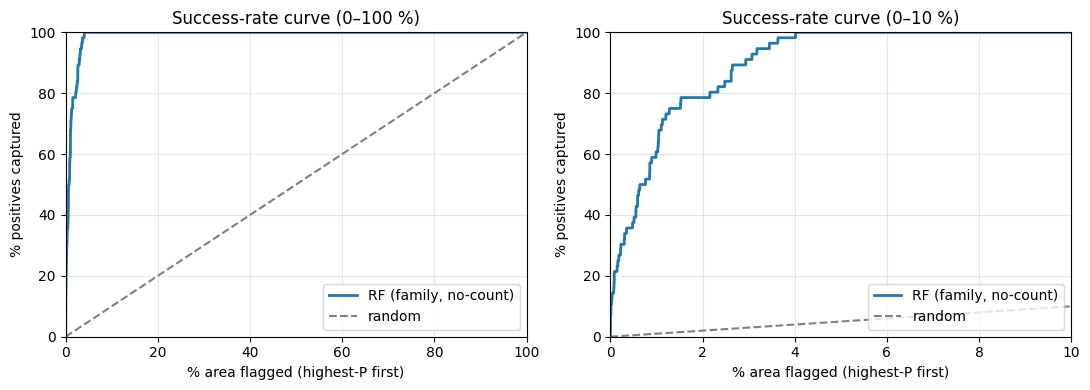

In [18]:
frac_area, frac_dep = success_rate_curve(p_fam, fam_mask.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xmax in zip(axes, [1.0, 0.10]):
    ax.plot(frac_area*100, frac_dep*100, lw=2, label="RF (family, no-count)")
    ax.plot([0, xmax*100], [0, xmax*100], ls="--", c="grey", label="random")
    ax.set_xlim(0, xmax*100); ax.set_ylim(0, 100)
    ax.set_xlabel("% area flagged (highest-P first)")
    ax.set_ylabel("% positives captured")
    ax.set_title(f"Success-rate curve (0–{int(xmax*100)} %)")
    ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout()

print("| area flagged | positives captured |")
for pct in [0.005, 0.01, 0.02, 0.05, 0.10]:
    k = max(0, min(int(pct * len(frac_area)) - 1, len(frac_area)-1))
    print(f"|   {pct*100:4.1f} %     |     {frac_dep[k]*100:4.1f} %          |")

Top 2 % of area captures 80 % of ARDF positives; top 5 % captures all
of them. The lift against training labels is steep. Whether that
translates to generalization on unseen drill outcomes is the question
the BCGT distribution-based blind test answers.

## Summary

| Check | Result | Status |
|---|---|---|
| 20 km spatial block CV | LR 0.92 / RF 0.88 ROC-AUC, sd ≈ 0.2 | ✓ passes |
| SHAP on no-count RF | Top features are Ag/Te/Mo/Cu pathfinder halo | ✓ geologically coherent |
| Training-label capture | Top 2 % area → 80 % of positives | ✓ strong |
| Strict-21a sensitivity | Same pathfinder suite; ~90 % top-1 % capture for strict positives | ✓ label choice robust |
| Rainbow Ridge NaN-S2 blind | Captured at top-5 % even with training exclusion | ✓ weak-positive generalization |
| PU-bagging baseline | ~60 % top-1000 rank overlap with pseudo-neg RF | PU doesn't strictly dominate |
| `<el>_has_data` indicators | Out-of-top-15 importance | NaN channel is minor |
| No-geochem baseline | Training capture rises without geochem | ARDF positives cluster tightly in non-geochem features too |
| External blind test | (not run here — see [BCGT](../bcgt/bcgt_porphyry_prospectivity.qmd)) | — |

## What this does and doesn't demonstrate

**Eastern Alaska v1 demonstrates, honestly:**

- A reproducible end-to-end MPM pipeline on public open data.
- Correct methodology: spatial block CV, pseudo-negative stratification,
  SHAP interpretation, sensitivity battery, PU-learning comparison.
- SHAP attributions that match textbook porphyry geochemistry
  (Ag/Te/Mo/Cu/Sb/Au/Pb pathfinder halo).
- A three-channel decomposition of the exploration bias that
  pseudo-supervised MPM admits — and an honest finding that feature-
  engineering fixes (`has_data` indicators, dropping `*_count_5km`)
  close only the obvious channel, not the dominant one.

**Eastern Alaska v1 does NOT demonstrate:**

- That the model would find unrecognized mineralization in unexplored
  terrain. Whether a pseudo-supervised pipeline generalizes out of
  distribution is the question the BCGT distribution-based blind test
  answers — see [BCGT integrated report](../bcgt/bcgt_porphyry_prospectivity.qmd).
- That multi-deposit-class labels work in one pooled model. EastAK is
  single-commodity (porphyry Cu-Mo-Au-Ag); BCGT adds epithermal +
  skarn + VMS and pools them.
- That 500 m regional-scale features can distinguish a distal low-grade
  porphyry hit from background. That's a scale-and-physics problem
  regional features don't solve; see v1.2 next steps for the direction
  that would.

**The honest posture for a reviewer:** everything in this document is
what the MPM literature has been naming and actively working on for
fifteen years. The three-channel decomposition of the exploration bias
is the non-obvious part; the recognition that "drop the biased feature"
doesn't fix it is the part that changes how the next iteration should
be built. The distribution-level confirmation that this matters
empirically is in the v2 BCGT track.

## Next steps — what v1.2 would do {#next-steps}

Given the v1 bias diagnosis, a second-version architecture would look very different:

1. **Prospect-scale features.** ASTER SWIR (VNIR 15 m / SWIR 30 m) mapping of alteration mineralogy — argillic, phyllic, propylitic halos. EMIT hyperspectral (60 m, selective scenes) for finer mineralogical discrimination. These are measured on regular grids independent of AGDB4 sampling history; they don't carry the exploration bias.
2. **Physics-consistent inversions.** [SimPEG](https://simpeg.xyz/) 2.5D magnetic + gravity inversions to produce *subsurface* susceptibility / density distributions, not surface-grid values. Strong prior at this cost: susceptibility peaks at 200–1000 m depth are the model anomaly for a porphyry stock.
3. **End-to-end PU learning.** Replace pseudo-negative sampling at the *labels* level, not just as a post-hoc ranking comparison. Weighted-PU / bagging-SVM / Elkan-Noto calibration. [Yin et al. 2025](https://www.sciencedirect.com/science/article/pii/S0169136825003439) is the state-of-art reference.
4. **Exploration-effort covariates.** Instead of dropping `*_count_5km`, carry it as a covariate that a two-stage model marginalizes out. Partial-dependence against count. Propensity-score framing on "has-been-explored."
5. **Decision-theoretic framing.** Rather than "rank cells," ask "where is P(deposit) × value-of-information highest given current posterior uncertainty?" POMDP drill planning per Mern et al. and the Caers Mineral-X line. This is what ExploreTech's Intelligent Prospector and KoBold's Stanford collaboration already do — for good reason, because the rank is not the answer, the *next drill hole* is.
6. **Geospatial foundation-model features.** [GFM4MPM (Daruna et al. 2024)](https://arxiv.org/abs/2406.12756) pretrains on unlabeled geospatial data with masked-image-modeling; its embeddings are a ready-made feature set for downstream MPM. [SpectralGPT](https://arxiv.org/abs/2311.07113) / [Prithvi](https://arxiv.org/abs/2310.18660) / [Clay](https://clay-foundation.github.io/model/) are general-RS alternatives.
7. **Dark-data ingestion.** OCR / VLM-based structured extraction from legacy assessment reports, scanned drill logs, and historical assays. This is the "dark data" rhetoric KoBold uses publicly and it's tractable with modern document AI (Azure Document Intelligence, Textract, or VLMs). A planned follow-up sub-project in this repo applies this to family-held 1900s Nome-area drill logs.
8. **Extend to a second commodity.** Orogenic Au in the California Mother Lode is the planned v2 region/commodity — reuses most of this scaffolding, tests generalization across deposit types.

## Reproducibility

This repository is designed to run end-to-end from a fresh environment.

```bash
# clone + install
git clone <repo>
cd ai-minerals
uv sync                                    # locked dependencies

# fetch raw data (~5 GB, takes ~1 hr)
uv run python -m ai_minerals.data.fetch.all

# build features (regenerates data/derived/features_eastak_500m.parquet)
uv run python -m ai_minerals.features.assemble

# render this notebook
quarto render notebooks/eastak_porphyry_prospectivity.qmd
# or execute as jupyter:
uv run jupyter nbconvert --to notebook --execute --inplace \
  notebooks/eastak_porphyry_prospectivity.ipynb
```

`pyproject.toml` pins Python 3.11+; `uv.lock` pins every transitive dependency. The notebook has no hidden state between cells — restart-and-run-all passes. Raw data is regenerable from the fetch modules in [`src/ai_minerals/data/`](../../src/ai_minerals/data/); nothing large is tracked in git.

## Code + design tour

- [`src/ai_minerals/aoi.py`](../../src/ai_minerals/aoi.py) — AOI and CRS constants.
- [`src/ai_minerals/grid.py`](../../src/ai_minerals/grid.py) — 500 m EPSG:3338 grid.
- [`src/ai_minerals/features/`](../../src/ai_minerals/features/) — labels, rasters, geology, geochem, assemble.
- [`src/ai_minerals/model.py`](../../src/ai_minerals/model.py) — pseudo-negatives, spatial block CV, LR baseline, success-rate curve.
- [`src/ai_minerals/model_rf.py`](../../src/ai_minerals/model_rf.py) — RF / HGB factories, tree spatial CV, count-feature helper.
- [`src/ai_minerals/model_pu.py`](../../src/ai_minerals/model_pu.py) — Mordelet-&-Vert PU bagging with OOB averaging.
- [`design/mvp-proposal.md`](../../design/mvp-proposal.md) — scoping document with v1 / v1.1 trace.
- [`notebooks/day{3,4,5}_*.qmd`](../../notebooks/) — day-by-day build log; audit trail for how the results above came together.

## References (primary sources)

- **Data:** [USGS MRDS](https://mrdata.usgs.gov/mrds/), [USGS ARDF](https://mrdata.usgs.gov/ardf/), [USGS AGDB4](https://www.sciencebase.gov/catalog/item/622a4ec7d34e4bb2bc5cad93), USGS SGMC, [Copernicus GLO-30 DEM](https://spacedata.copernicus.eu/en/collections/copernicus-digital-elevation-model), [Sentinel-2 L2A](https://sentinels.copernicus.eu/web/sentinel/missions/sentinel-2), [Alaska DGGS](https://dggs.alaska.gov/).
- **MPM methodology:** [Carranza 2017 — "Natural Resources Research" 26](https://link.springer.com/article/10.1007/s11053-017-9334-7); [MDPI Minerals 2025 MPM/ML review](https://www.mdpi.com/2075-163X/15/10/1042).
- **Pseudo-negatives + PU learning:** [Yin et al. 2025, Ore Geology Reviews](https://www.sciencedirect.com/science/article/pii/S0169136825003439); [Carranza & Laborte 2015, Computers & Geosciences](https://www.sciencedirect.com/science/article/pii/S009830041500085X).
- **Spatial block CV:** [Roberts et al. 2017, Ecography](https://onlinelibrary.wiley.com/doi/10.1111/ecog.02881); applied to MPM in EarthByte's [DEEP-SEAM 2025](https://egusphere.copernicus.org/preprints/2025/egusphere-2025-3283/).
- **Decision-theoretic exploration:** [Intelligent Prospector v1 (GMD 2023)](https://gmd.copernicus.org/articles/16/289/2023/); [v2 (arXiv 2024)](https://arxiv.org/pdf/2410.10610).
- **Foundation models for MPM:** [GFM4MPM — Daruna et al. 2024](https://arxiv.org/abs/2406.12756).
- **Validation data:** See the [BCGT integrated report](../bcgt/bcgt_porphyry_prospectivity.qmd) for the distribution-based blind test. Primary source: [BCGS GeoFile 2025-11 Assessment Report Drillhole Database](https://cmscontent.nrs.gov.bc.ca/geoscience/PublicationCatalogue/GeoFile/BCGS_GF2025-11.zip).
- **Deposit models:** Cox & Singer (1986), USGS Bulletin 1693 "Mineral Deposit Models" — codes 17, 20c, 21a, 21b.

*Sky King · 2026 · contact via the email in this repo's GitHub profile.*